##Objective
To perform clustering on a given dataset using the K-Medoids (PAM – Partitioning Around Medoids) algorithm, and to group similar data points into clusters by minimizing the total dissimilarity.


##Method Used (Algorithm)

We used the K-Medoids clustering algorithm (PAM).

🔹 Steps:
Select k = 2 initial medoids (given: 2 and 10).

Compute distance using:

𝑑
(
𝑥
,
𝑦
)
=
∣
𝑥
−
𝑦
∣
d(x,y)=∣x−y∣
Assign each point to the nearest medoid.
For each cluster:
Compute total distance of each point to others.
Choose the point with minimum total distance as new medoid.
Repeat until medoids do not change (convergence).

In [1]:
import numpy as np

# Data points
points = np.array([2, 4, 5, 10, 12])

k = 2
medoids = [2, 10]  # initial medoids

def assign_clusters(points, medoids):
    clusters = {m: [] for m in medoids}

    for p in points:
        distances = [abs(p - m) for m in medoids]
        nearest = medoids[np.argmin(distances)]
        clusters[nearest].append(p)

    return clusters

def update_medoids(clusters):
    new_medoids = []

    for m, cluster in clusters.items():
        min_cost = float('inf')
        best_medoid = None

        for candidate in cluster:
            cost = sum(abs(candidate - x) for x in cluster)
            if cost < min_cost:
                min_cost = cost
                best_medoid = candidate

        new_medoids.append(best_medoid)

    return new_medoids

# PAM Iteration
for _ in range(10):
    clusters = assign_clusters(points, medoids)
    new_medoids = update_medoids(clusters)

    if set(new_medoids) == set(medoids):
        break

    medoids = new_medoids

print("Final Medoids:", medoids)
print("Clusters:", clusters)

Final Medoids: [np.int64(4), np.int64(10)]
Clusters: {np.int64(4): [np.int64(2), np.int64(4), np.int64(5)], np.int64(10): [np.int64(10), np.int64(12)]}


##Interpretation of Results
The dataset was divided into two clusters based on proximity.
Points (2, 4, 5) are closer to each other → form Cluster 1.
Points (10, 12) are closer → form Cluster 2.

Updated medoids:

Cluster 1 → 4 (most central point)
Cluster 2 → 10

This shows that:

4 represents lower-value group
10 represents higher-value group

##Conclusion
The K-Medoids algorithm successfully grouped the data into meaningful clusters.
Final clusters:
C1 = {2, 4, 5}
C2 = {10, 12}
Final medoids:
4 and 10

✅ Unlike K-Means, K-Medoids:

Uses actual data points as centers
Is more robust to outliers

Hence, K-Medoids is suitable for datasets where noise or extreme values may affect clustering.

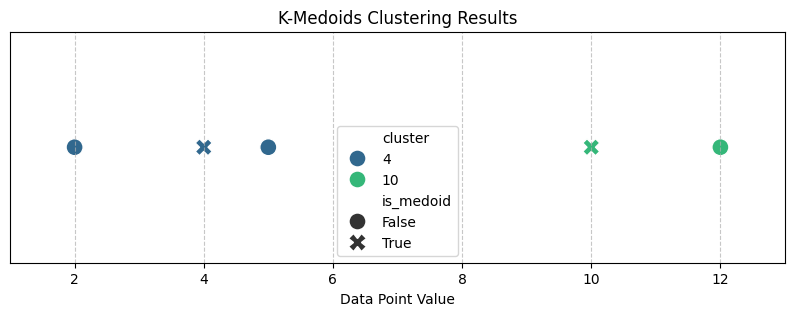

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd # Import pandas

# Prepare data for plotting
plot_data = []
for medoid, cluster_points in clusters.items():
    for point in cluster_points:
        plot_data.append({'point': point, 'cluster': str(medoid), 'is_medoid': (point == medoid)})

df_plot = pd.DataFrame(plot_data)

plt.figure(figsize=(10, 3))
sns.scatterplot(
    x='point',
    y=np.zeros(len(df_plot)), # Use a dummy y-axis for 1D visualization
    hue='cluster',
    style='is_medoid',
    markers={True: 'X', False: 'o'},
    s=150, # Size of points
    data=df_plot,
    palette='viridis', # Color palette
    legend='full'
)

# Annotate points if desired (optional)
# for i, row in df_plot.iterrows():
#     plt.text(row['point'], 0.05, str(row['point']), horizontalalignment='center', size='small', color='black', weight='semibold')

plt.title('K-Medoids Clustering Results')
plt.xlabel('Data Point Value')
plt.yticks([]) # Hide y-axis ticks
plt.gca().get_yaxis().set_visible(False) # Hide y-axis
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.xlim(min(points) - 1, max(points) + 1) # Set x-axis limits
plt.show()